<a href="https://colab.research.google.com/github/AditiAICodes/Autobahn-Data-Analysis/blob/main/Phase_3/01_Baseline_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import userdata

# This pulls your token from the vault and sets it as the environment variable
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_KEY')

print("✅ Active!")

✅ Active!


In [ ]:
!kaggle datasets list -s "predictive maintenance"

ref                                                             title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  ------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
shivamb/machine-predictive-maintenance-classification           Machine Predictive Maintenance Classification         139819  2021-11-06 02:59:26.113000          47524        408                1  
prognosticshse/preventive-to-predicitve-maintenance             Preventive to Predictive Maintenance                 3169508  2024-06-13 15:31:12.753000           4530         52                1  
arnabbiswas1/microsoft-azure-predictive-maintenance             Microsoft Azure Predictive Maintenance              32497141  2020-10-15 06:56:49.803000          18246        140        0.7058824  
hiimanshua

In [ ]:
# 1. TELEPORT the automotive engine data
!kaggle datasets download -d "ziya07/engine-failure-detection-dataset"

# 2. UNZIP the file (The -o means "Overwrite without asking!")
!unzip -o engine-failure-detection-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/ziya07/engine-failure-detection-dataset
License(s): CC0-1.0
engine-failure-detection-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  engine-failure-detection-dataset.zip
  inflating: engine_failure_dataset.csv  


In [ ]:
import pandas as pd

# Using the EXACT lowercase name from the unzip output
df_engine = pd.read_csv('engine_failure_dataset.csv')

# Show the first 5 rows
df_engine.head()

,Time_Stamp,Temperature (°C),RPM,Fuel_Efficiency,Vibration_X,Vibration_Y,Vibration_Z,Torque,Power_Output (kW),Fault_Condition,Operational_Mode
0,2024-12-24 10:00:00,60.308585,3426.827588,20.445472,0.874657,0.005686,0.529798,107.877659,23.367684,2,Idle
1,2024-12-24 10:05:00,112.705055,2949.758424,23.083947,0.696461,0.391779,0.124336,60.351655,57.941022,3,Cruising
2,2024-12-24 10:10:00,108.670976,1817.971040,20.555326,0.495276,0.189714,0.886417,110.986564,47.732998,2,Cruising
3,2024-12-24 10:15:00,107.114691,2730.660539,23.226431,0.986206,0.983202,0.468114,77.416793,44.112039,2,Cruising
4,2024-12-24 10:20:00,118.075814,1854.488677,21.148226,0.710810,0.101139,0.481034,100.475881,80.681972,2,Cruising


In [ ]:
#A)EDA (Exploratory Data Analysis)

#EDA Phase 1: Surface-level scan
#Surface EDA → what is the data?

# 1. Check the data types and see if any rows are missing (NaN)
print("--- ENGINE DATA INFO ---")
df_engine.info()
print("")

# 2. Get the statistical summary (Mean, Max, Min)
print("\n--- STATISTICAL SUMMARY ---")
df_engine.describe()



--- ENGINE DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Time_Stamp         1000 non-null   object 
 1   Temperature (°C)   1000 non-null   float64
 2   RPM                1000 non-null   float64
 3   Fuel_Efficiency    1000 non-null   float64
 4   Vibration_X        1000 non-null   float64
 5   Vibration_Y        1000 non-null   float64
 6   Vibration_Z        1000 non-null   float64
 7   Torque             1000 non-null   float64
 8   Power_Output (kW)  1000 non-null   float64
 9   Fault_Condition    1000 non-null   int64  
 10  Operational_Mode   1000 non-null   object 
dtypes: float64(8), int64(1), object(2)
memory usage: 86.1+ KB


--- STATISTICAL SUMMARY ---


,Temperature (°C),RPM,Fuel_Efficiency,Vibration_X,Vibration_Y,Vibration_Z,Torque,Power_Output (kW),Fault_Condition
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,90.504323,2512.321847,22.490255,0.500771,0.502289,0.483137,123.574345,58.881629,1.465000
std,17.255081,867.543649,4.422922,0.294531,0.281046,0.288449,42.897150,22.535297,1.106345
min,60.013118,1000.737383,15.045726,0.000170,0.000741,0.001086,50.059144,20.148910,0.000000
25%,75.708728,1757.938417,18.634425,0.234537,0.264195,0.233457,85.735962,40.220009,0.000000
50%,90.168595,2498.874857,22.433952,0.519200,0.503314,0.461902,122.377927,58.850054,1.000000
75%,105.478252,3273.470646,26.448111,0.752874,0.744645,0.737903,160.091056,78.345886,2.000000
max,119.982191,3996.039482,29.998912,0.999893,0.999531,0.999384,199.909402,99.932956,3.000000


In [ ]:
# 3. See how many 'Failures' vs 'Normal' states we have
print("\n--- FAULT CONDITION COUNTS ---")
print(df_engine['Fault_Condition'].value_counts())


--- FAULT CONDITION COUNTS ---
Fault_Condition
2    265
0    258
1    248
3    229
Name: count, dtype: int64


In [ ]:
#EDA Phase 2: Relationship understanding
#Relationship EDA → how variables interact?

# Pick target = Fault conditions then Check how does temparature affect Fault conditions

#1. Mean (quick signal)
df_engine.groupby("Fault_Condition")["Temperature (°C)"].mean()
#Now THINK:
#does temperature increase with higher fault?
#is difference big or small?



,Temperature (°C)
Fault_Condition,
0,90.845686
1,90.152556
2,91.195946
3,89.700333


In [ ]:
#2. Describe (spread + variation)
df_engine.groupby("Fault_Condition")["Temperature (°C)"].describe()

,count,mean,std,min,25%,50%,75%,max
Fault_Condition,,,,,,,,
0,258.0,90.845686,17.156101,60.014548,76.683594,90.873795,106.729089,119.910088
1,248.0,90.152556,16.388557,60.013118,76.720125,89.486459,103.759465,119.982191
2,265.0,91.195946,18.289112,60.038016,75.019662,91.964975,108.337025,119.924121
3,229.0,89.700333,17.118659,60.410233,74.493521,89.036909,104.004740,119.942807


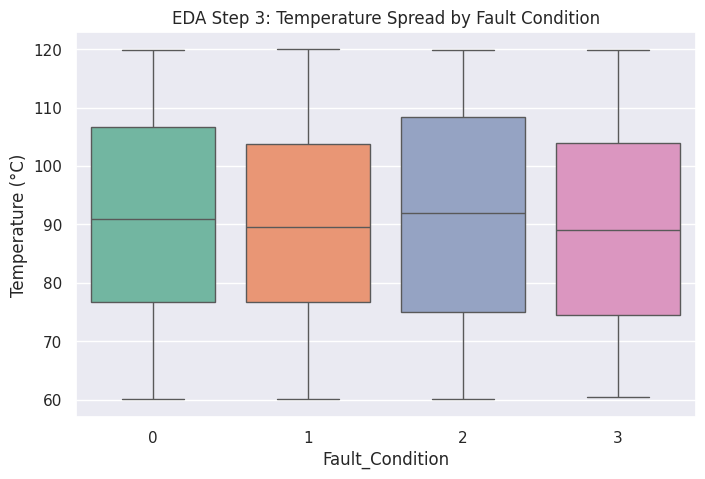

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style
sns.set_theme(style="darkgrid")

# Draw the boxplot for Temperature
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Fault_Condition",
    y="Temperature (°C)",
    data=df_engine,
    hue="Fault_Condition",
    palette="Set2",
    legend=False
)

# Add titles
plt.title("EDA Step 3: Temperature Spread by Fault Condition")
plt.show()

In [ ]:
#RPM
df_engine.groupby("Fault_Condition")["RPM"].describe()
#Is difference between classes big compared to variation inside class? If:YES → useful ,NO → weak

,count,mean,std,min,25%,50%,75%,max
Fault_Condition,,,,,,,,
0,258.0,2508.982049,847.692937,1004.237059,1697.551117,2449.509858,3265.707961,3991.186241
1,248.0,2536.183003,882.848393,1003.883466,1808.241973,2509.259218,3320.525830,3996.039482
2,265.0,2509.732296,880.202068,1030.379630,1741.531429,2519.017018,3273.638738,3964.422767
3,229.0,2493.240328,863.290439,1000.737383,1791.850242,2471.274030,3157.083255,3986.553708


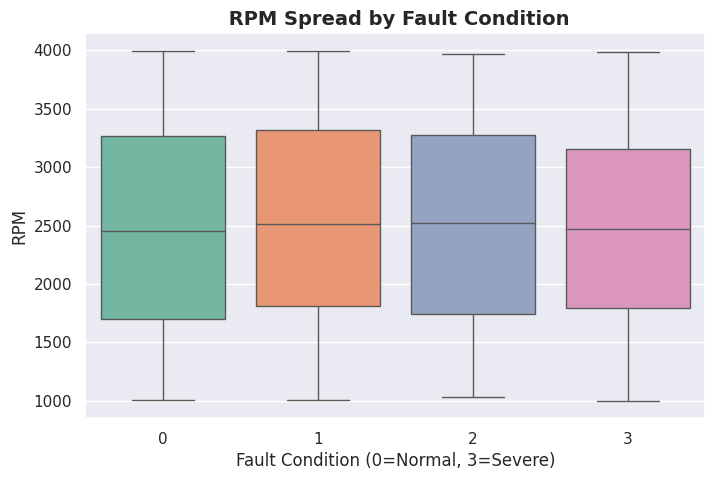

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# STEP 2: Boxplot (The Visual)
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Fault_Condition",
    y="RPM",
    data=df_engine,
    hue="Fault_Condition",
    palette="Set2",
    legend=False


)
plt.title(" RPM Spread by Fault Condition", fontsize=14, fontweight='bold')
plt.xlabel("Fault Condition (0=Normal, 3=Severe)")
plt.show()



In [ ]:
#Torque
#STEP 1: Describe (The Numbers)

df_engine.groupby("Fault_Condition")["Torque"].describe()



,count,mean,std,min,25%,50%,75%,max
Fault_Condition,,,,,,,,
0,258.0,117.152033,42.670190,50.059144,80.412158,113.327899,153.378630,198.798441
1,248.0,126.008798,42.126310,50.428853,90.135980,127.112323,160.237207,199.909402
2,265.0,127.529369,43.347558,51.655048,92.446607,128.422878,162.485779,198.793164
3,229.0,123.596750,42.906764,50.572835,87.372333,121.187223,159.937591,199.658652


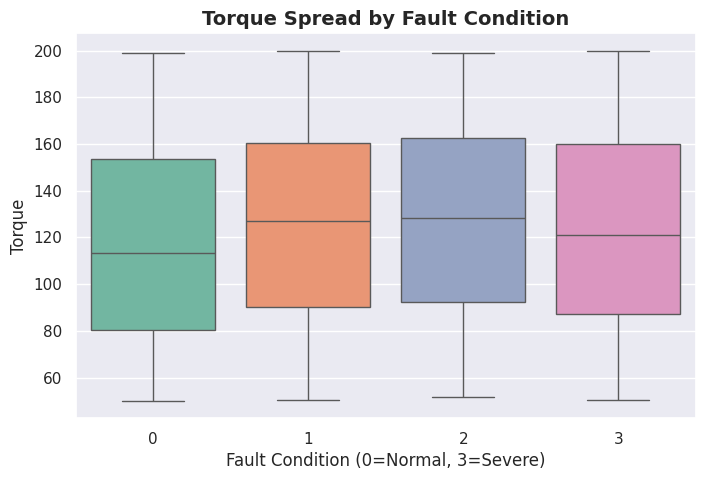

In [ ]:
#STEP 2: Boxplot (The Visual)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Fault_Condition",
    y="Torque",
    data=df_engine,
    hue="Fault_Condition",
    palette="Set2",
    legend=False
)
plt.title("Torque Spread by Fault Condition", fontsize=14, fontweight='bold')
plt.xlabel("Fault Condition (0=Normal, 3=Severe)")
plt.show()

In [ ]:
#VIBRATION X
#STEP 1: Describe (The Numbers)
df_engine.groupby("Fault_Condition")["Vibration_X"].describe()


,count,mean,std,min,25%,50%,75%,max
Fault_Condition,,,,,,,,
0,258.0,0.495077,0.287232,0.003400,0.241636,0.499920,0.733736,0.999893
1,248.0,0.489357,0.300750,0.002327,0.201456,0.534304,0.739547,0.996262
2,265.0,0.489886,0.290471,0.000465,0.246193,0.500942,0.731758,0.997344
3,229.0,0.532142,0.300185,0.000170,0.248068,0.543140,0.799731,0.995056


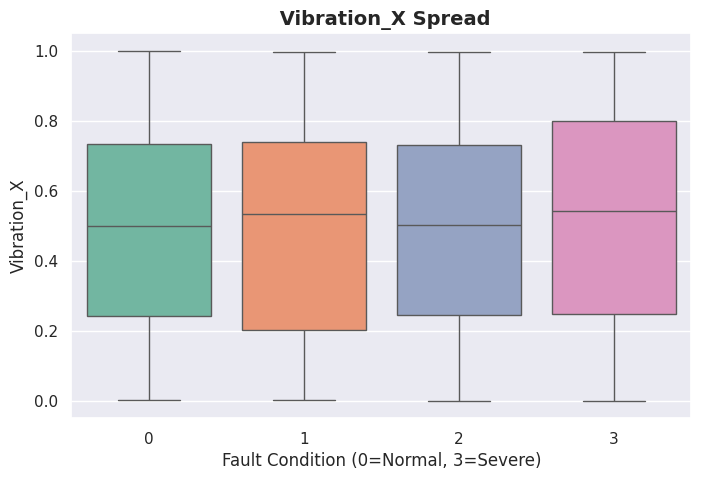

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
#STEP 2: Boxplot (The Visual)
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Fault_Condition",
    y="Vibration_X",
    data=df_engine,
    hue="Fault_Condition",
    palette="Set2",
    legend=False
)
plt.title(" Vibration_X Spread", fontsize=14, fontweight='bold')
plt.xlabel("Fault Condition (0=Normal, 3=Severe)")
plt.show()

In [ ]:
#VIBRATION Y
#STEP 1: Describe (The Numbers)
df_engine.groupby("Fault_Condition")["Vibration_Y"].describe()

,count,mean,std,min,25%,50%,75%,max
Fault_Condition,,,,,,,,
0,258.0,0.499424,0.268270,0.007418,0.273039,0.493303,0.741583,0.995869
1,248.0,0.522512,0.279667,0.002742,0.301851,0.538535,0.768315,0.994315
2,265.0,0.501210,0.285678,0.002691,0.259127,0.493085,0.752600,0.999531
3,229.0,0.484866,0.291506,0.000741,0.231925,0.486124,0.742218,0.998463


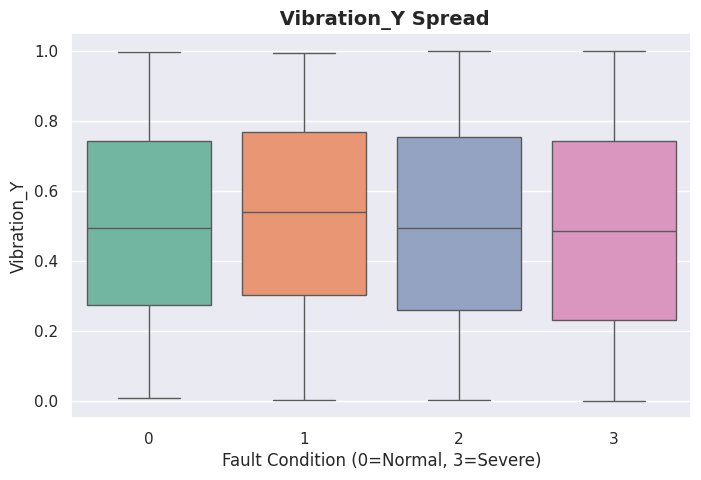

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
#STEP 2: Boxplot (The Visual)
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Fault_Condition",
    y="Vibration_Y",
    data=df_engine,
    hue="Fault_Condition",
    palette="Set2",
    legend=False
)
plt.title(" Vibration_Y Spread", fontsize=14, fontweight='bold')
plt.xlabel("Fault Condition (0=Normal, 3=Severe)")
plt.show()

In [ ]:
#VIBRATION Z
#STEP 1: Describe (The Numbers)
df_engine.groupby("Fault_Condition")["Vibration_Z"].describe()

,count,mean,std,min,25%,50%,75%,max
Fault_Condition,,,,,,,,
0,258.0,0.492812,0.286784,0.003903,0.239824,0.480360,0.715026,0.999384
1,248.0,0.471060,0.301687,0.001462,0.225501,0.430935,0.754731,0.997065
2,265.0,0.488397,0.287373,0.001086,0.242645,0.458656,0.728712,0.995646
3,229.0,0.479229,0.278062,0.004066,0.230423,0.475038,0.706578,0.995648


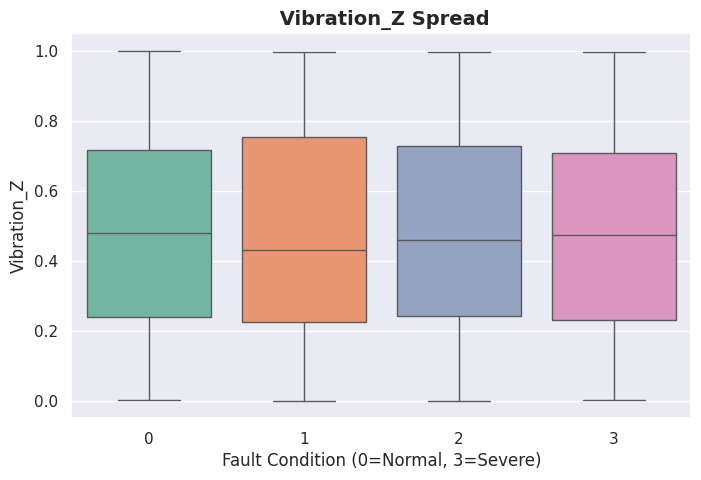

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
#STEP 2: Boxplot (The Visual)
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Fault_Condition",
    y="Vibration_Z",
    data=df_engine,
    hue="Fault_Condition",
    palette="Set2",
    legend=False
)
plt.title(" Vibration_Z Spread", fontsize=14, fontweight='bold')
plt.xlabel("Fault Condition (0=Normal, 3=Severe)")
plt.show()

In [ ]:
#B)FEATURE ENGINEERING: Creating new useful columns from existing ones
import numpy as np

df_engine['Total_Vibration'] = np.sqrt(
    df_engine['Vibration_X']**2 +
    df_engine['Vibration_Y']**2 +
    df_engine['Vibration_Z']**2
)
#STEP 1: Describe (The Numbers) for our Master Sensor
df_engine.groupby("Fault_Condition")["Total_Vibration"].describe()

,count,mean,std,min,25%,50%,75%,max
Fault_Condition,,,,,,,,
0,258.0,0.951135,0.262292,0.193274,0.764385,0.960781,1.132988,1.580079
1,248.0,0.954194,0.287866,0.185709,0.759546,0.986653,1.174186,1.611920
2,265.0,0.949476,0.275945,0.131118,0.759669,0.977890,1.143135,1.564846
3,229.0,0.960868,0.276224,0.110447,0.789863,0.995222,1.145392,1.673235


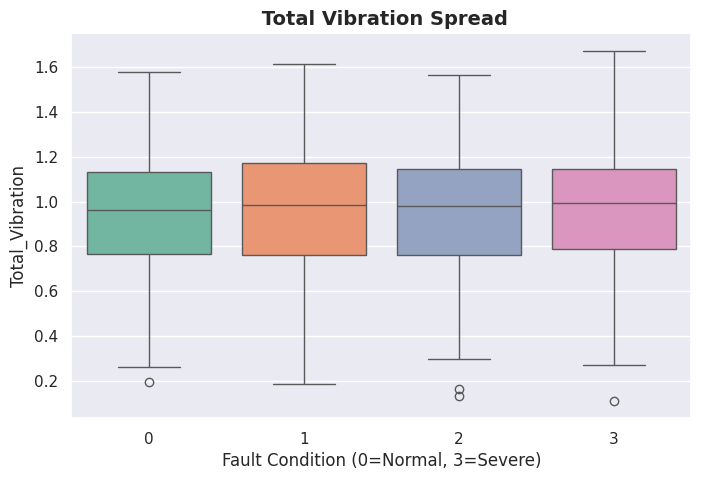

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# 2.BOXPLOT- THE VISUAL
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Fault_Condition",
    y="Total_Vibration",
    data=df_engine,
    hue="Fault_Condition",
    palette="Set2",
    legend=False
)
plt.title(" Total Vibration Spread", fontsize=14, fontweight='bold')
plt.xlabel("Fault Condition (0=Normal, 3=Severe)")
plt.show()

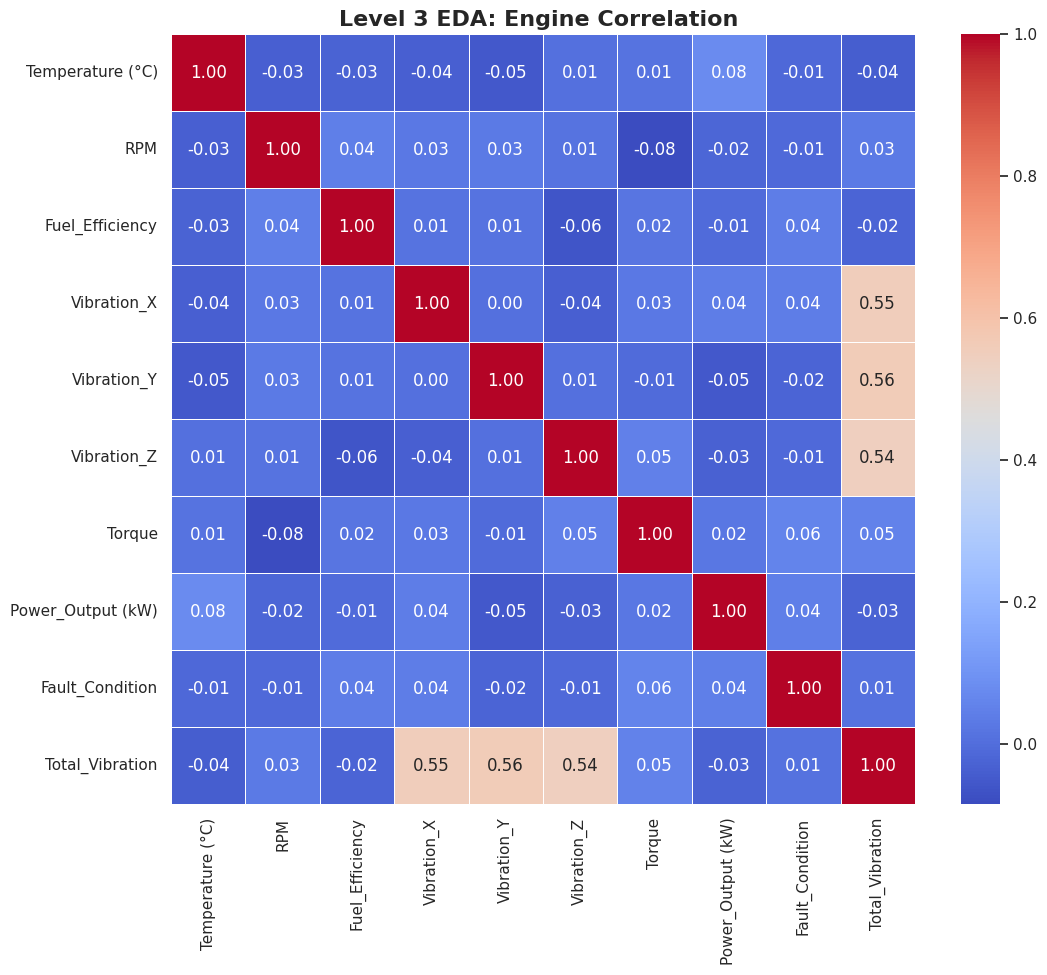

In [ ]:
#Advanced EDA
#Correlation:measures relationships between features
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the correlations
# (We only use numeric columns for this)
corr_matrix = df_engine.select_dtypes(include=[np.number]).corr()

# 2. Draw the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,      # Shows the actual numbers in the boxes
    cmap='coolwarm', # 🔴 Red → positive relation 🔵 Blue → negative relation ⚪ Near white → no relation
    fmt=".2f",       # Rounds to 2 decimal places
    linewidths=0.5
)

plt.title("Level 3 EDA: Engine Correlation ", fontsize=16, fontweight='bold')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Pick the sensors (We NEVER scale the 'Fault_Condition' target)
features_to_scale = ['Temperature (°C)', 'RPM', 'Torque', 'Total_Vibration']

# 3. Fit and Transform
df_engine[features_to_scale] = scaler.fit_transform(df_engine[features_to_scale])

print("✅ Step 5 Complete! Your engine data is scaled and ready for the AI.")
df_engine[features_to_scale].head()

✅ Step 5 Complete! Your engine data is scaled and ready for the AI.


,Temperature (°C),RPM,Torque,Total_Vibration
0,-1.750838,1.054660,-0.366098,0.250599
1,1.287264,0.504477,-1.474558,-0.527040
2,1.053356,-0.800765,-0.293588,0.288236
3,0.963118,0.251801,-1.076543,1.873939
4,1.598676,-0.758650,-0.538731,-0.325236


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Separate the "Questions" (Sensors) from the "Answer Key" (Fault Condition)
X = df_engine[['Temperature (°C)', 'RPM', 'Torque', 'Total_Vibration']]
y = df_engine['Fault_Condition']

# 2. Split the data (80% for the Study Guide, 20% for the hidden Final Exam)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Build the blank ML Model
ai_brain = RandomForestClassifier(random_state=42)

# 4. Teach the machine (This is the actual "Machine Learning" part!)
print("The AI is studying your engine data...")
ai_brain.fit(X_train, y_train)

# 5. Force the AI to take the Final Exam on the hidden data
predictions = ai_brain.predict(X_test)

# 6. Grade the Exam!
score = accuracy_score(y_test, predictions)
print(f" SCORE: {score * 100}% Accuracy")

The AI is studying your engine data...
 SCORE: 23.5% Accuracy
